# UK Peptides Interest -- EDA Roadmap

An interactive, section-by-section guide through exploratory analysis of the
star schema in `database/schema.sql`. Starter cells load and count data;
notebook is a roadmap, not a finished analysis.

Covers every KPI and success metric defined in
`data/data_dictionary/Peptides_UK_Setup_Info.xlsx` (Success Metrics + KPIs
sheets), so nothing in the project brief is left unaddressed.

## 0. Setup & Connection

`region_id` is **nullable** in both `fact_search_interest` (Wikipedia
pageviews have no UK-region breakdown) and `fact_events` -- keep that in
mind anywhere you group or filter by region.

In [1]:
import sys
from pathlib import Path

# so `from src.load.db import get_connection` resolves when Jupyter's cwd
# is notebooks/ rather than the repo root
sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.load.db import get_connection

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

conn = get_connection()

In [2]:
peptides = pd.read_sql("SELECT * FROM dim_peptides", conn)
regions = pd.read_sql("SELECT * FROM dim_regions", conn)
sources = pd.read_sql("SELECT * FROM dim_sources", conn)
dates = pd.read_sql("SELECT * FROM dim_dates", conn)
search_interest = pd.read_sql("SELECT * FROM fact_search_interest", conn)
events = pd.read_sql("SELECT * FROM fact_events", conn)

for name, df in [
    ("peptides", peptides), ("regions", regions), ("sources", sources),
    ("dates", dates), ("search_interest", search_interest), ("events", events),
]:
    print(f"{name}: {len(df)} rows")

peptides: 9 rows
regions: 4 rows
sources: 5 rows
dates: 209 rows
search_interest: 3292 rows
events: 334 rows


C:\Users\aw11c\AppData\Local\Temp\ipykernel_20764\1959606841.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  peptides = pd.read_sql("SELECT * FROM dim_peptides", conn)
C:\Users\aw11c\AppData\Local\Temp\ipykernel_20764\1959606841.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  regions = pd.read_sql("SELECT * FROM dim_regions", conn)
C:\Users\aw11c\AppData\Local\Temp\ipykernel_20764\1959606841.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sources = pd.read_sql("SELECT * FROM dim_sources", conn)
C:\Users\aw11c\Ap

## 1. Data Quality & Sanity Checks

Expected row counts: `dim_peptides`=9, `dim_regions`=4, `dim_sources`=5,
`dim_dates`=209, `fact_search_interest`=3292, `fact_events`=334.

In [3]:
print("Null counts per table:")
for name, df in [
    ("peptides", peptides), ("regions", regions), ("sources", sources),
    ("dates", dates), ("search_interest", search_interest), ("events", events),
]:
    nulls = df.isna().sum()
    print(f"\n{name}:")
    print(nulls[nulls > 0] if nulls.any() else "  none")

Null counts per table:

peptides:
  none

regions:
  none

sources:
  none

dates:
  none

search_interest:
region_id    3220
dtype: int64

events:
region_id    334
dtype: int64


In [4]:
# region_id null-rate by source -- expect 100% null for Wikipedia,
# 0% for Google Trends' regional rows
source_lookup = sources.set_index("source_id")["source_name"]

(
    search_interest
    .assign(source_name=search_interest["source_id"].map(source_lookup))
    .groupby("source_name")["region_id"]
    .apply(lambda s: s.isna().mean())
    .rename("pct_null_region_id")
)

source_name
Google Trends    0.959391
Wikipedia        1.000000
Name: pct_null_region_id, dtype: float64

## 2. Dimension Profiling

In [6]:
display(peptides[["primary_usage", "price_range", "approved"]].describe(include="all"))
display(regions.sort_values("population", ascending=False))
display(sources.sort_values("reliability", ascending=False))
print("Date range:", dates["date"].min(), "to", dates["date"].max())

,primary_usage,price_range,approved
count,9,9,9
unique,9,1,2
top,"gastric/tissue injury repair, studied mainly i...",NaN,False
freq,1,9,8


,region_id,region_name,population
0,1,England,58620101
1,2,Scotland,5546900
2,3,Wales,3186581
3,4,Northern Ireland,1927855


,source_id,source_name,reliability
4,5,ONS,10
1,2,PubMed,9
0,1,Google Trends,7
3,4,Wikipedia,6
2,3,GDELT,5


Date range: 2023-01-01 to 2026-12-27


## 3. Univariate Distribution of Search Interest

Google Trends scores are 0-100; Wikipedia scores
are raw pageviews -- **not the same scale**. Keep sources separate until
you've decided whether/how to normalise.

,count,mean,std,min,25%,50%,75%,max
source_name,,,,,,,,
Google Trends,1773.0,4.996898,12.074572,0.0,0.00000,0.000000,3.000000,89.0
Wikipedia,1519.0,40.763888,24.004437,0.0,22.25431,40.616883,57.015713,100.0


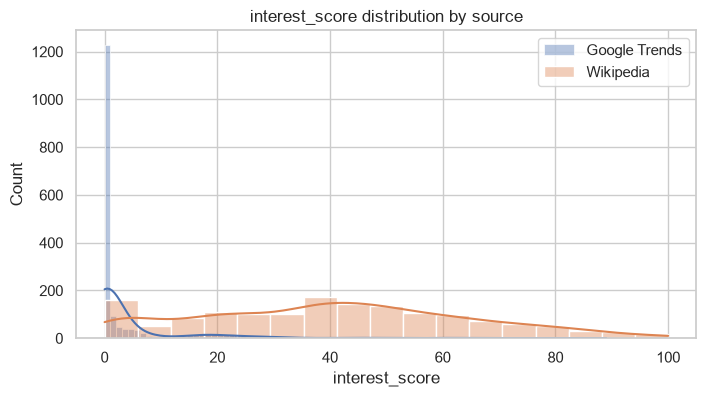

In [8]:
si = (
    search_interest
    .merge(peptides[["peptide_id", "peptide_name"]], on="peptide_id")
    .merge(sources[["source_id", "source_name"]], on="source_id")
)

display(si.groupby("source_name")["interest_score"].describe())

fig, ax = plt.subplots(figsize=(8, 4))
for source_name, group in si.groupby("source_name"):
    sns.histplot(group["interest_score"], label=source_name, kde=True, ax=ax, alpha=0.4)
ax.legend()
ax.set_title("interest_score distribution by source")
plt.show()

## 4. Time-Series Trends per Peptide

In [10]:
national = si.merge(dates[["date_id", "date"]], on="date_id")

trend = (
    national
    .groupby(["date", "peptide_name", "source_name"])["interest_score"]
    .mean()
    .reset_index()
)
trend.head()

,date,peptide_name,source_name,interest_score
0,2023-01-01,BPC-157,Google Trends,2.200000
1,2023-01-01,BPC-157,Wikipedia,14.386486
2,2023-01-01,CJC-1295,Google Trends,0.100000
3,2023-01-01,CJC-1295,Wikipedia,22.500000
4,2023-01-01,Epitalon,Google Trends,0.300000


## 5. Regional Analysis

Filters to rows with a non-null `region_id` -- national-only and Wikipedia
rows are excluded here by construction.

In [12]:
regional = (
    search_interest[search_interest["region_id"].notna()]
    .merge(regions, on="region_id")
    .merge(peptides[["peptide_id", "peptide_name"]], on="peptide_id")
    .merge(dates[["date_id", "date"]], on="date_id")
)
regional.head()

,date_id,peptide_id,region_id,source_id,interest_score,region_name,population,peptide_name,date
0,20230101,1,4.0,1,4.0,Northern Ireland,1927855,BPC-157,2023-01-01
1,20230101,1,3.0,1,2.0,Wales,3186581,BPC-157,2023-01-01
2,20230101,1,1.0,1,2.0,England,58620101,BPC-157,2023-01-01
3,20230101,1,2.0,1,3.0,Scotland,5546900,BPC-157,2023-01-01
4,20260510,1,1.0,1,4.0,England,58620101,BPC-157,2026-05-10


## 6. Cross-Source Comparison (Multi-Source Validation)

Google Trends and Wikipedia are two independent signals of the same
underlying interest. Agreement between them is part of the project's
">=3 independent sources" success metric (together with Section 7's
events data as a third).

In [14]:
by_source = (
    national
    .pivot_table(index=["date", "peptide_name"], columns="source_name", values="interest_score")
    .reset_index()
)
by_source.head()

source_name,date,peptide_name,Google Trends,Wikipedia
0,2023-01-01,BPC-157,2.2,14.386486
1,2023-01-01,CJC-1295,0.1,22.500000
2,2023-01-01,Epitalon,0.3,32.124049
3,2023-01-01,GHK-Cu,0.2,0.568182
4,2023-01-01,Ipamorelin,3.4,38.500421


## 7. Events Exploration

`category` distinguishes the two sources combined into `fact_events`:
`"News/Media"` (GDELT) vs. `"Clinical research"` (PubMed).

category
Clinical research    242
News/Media            92
Name: count, dtype: int64

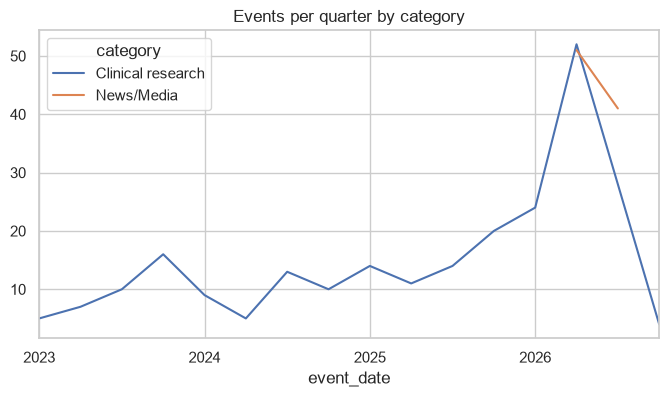

peptide_name
Retatrutide    93
BPC-157        54
GHK-Cu         48
Semaglutide    41
Tesamorelin    27
CJC-1295       19
TB-500         19
Ipamorelin     17
Epitalon       16
dtype: int64

In [16]:
ev = events.merge(peptides[["peptide_id", "peptide_name"]], on="peptide_id")
ev["event_date"] = pd.to_datetime(ev["event_date"])

display(ev["category"].value_counts())

fig, ax = plt.subplots(figsize=(8, 4))
ev.groupby([pd.Grouper(key="event_date", freq="QE"), "category"]).size().unstack().plot(ax=ax)
ax.set_title("Events per quarter by category")
plt.show()

display(ev.groupby("peptide_name").size().sort_values(ascending=False))

## 8. Event-to-Search-Interest Lift Analysis

KPI 6, **Event-Associated Excess Search Lift (%)**:

1. `SearchLift = (Post-Event Interest - Pre-Event Interest) / Pre-Event Interest x 100`
2. `BaselineLift = (Post-Baseline Interest - Pre-Baseline Interest) / Pre-Baseline Interest x 100`
3. `Excess Lift = SearchLift - BaselineLift`

The baseline period should be a comparable window with no event, so the
result isolates the event's incremental effect rather than a general trend.



In [ ]:
def compute_event_lift(peptide_id, event_date, window_days):
    """Return the excess search lift (%) for one event.

    TODO: pull search_interest for `peptide_id` in the pre/post windows
    around `event_date`, compute SearchLift, compute BaselineLift from a
    comparable no-event window, and return SearchLift - BaselineLift.
    """
    raise NotImplementedError

## 9. KPI Calculations

One subsection per KPI defined in the `KPIs` sheet of
`Peptides_UK_Setup_Info.xlsx`.

### 9.1 Overall UK Search Interest Growth (%)

`(Current Period Interest - Baseline Period Interest) / Baseline Period Interest x 100`

### 9.2 Year-over-Year Growth (%)

Same formula as 9.1, comparing the current period to the same period one
year prior.

### 9.3 Top Growing Peptide

Per-peptide growth % (same formula), ranked descending.

### 9.4 Fastest Growing UK Region

Per-region growth % (using Section 5's `regional` DataFrame), ranked
descending.

### 9.5 Largest Search Spike

`(Peak Interest - Expected/Baseline Interest) / Expected Interest x 100`

### 9.6 Event-Associated Excess Search Lift (%)

Apply `compute_event_lift` from Section 8 across all events once it's
implemented.

### 9.7 Event Attribution Rate (%)

`Attribution Spikes / Total Major Spikes x 100` -- requires Section 9.5's
spike list and Section 9.6's lift results to decide which spikes are
event-attributable.

### 9.8 Most Common User Intent

`Searches/Responses for Intent / Total Relevant Searches/Responses x 100`

**Data gap:** there is no "user intent" column anywhere in the schema.
`dim_peptides.primary_usage` (free-text known effects, e.g. "promoting
tissue repair") is the closest available proxy, but it describes the
peptide, not what a given search/user was after. Computing this KPI as
specified would need new data (e.g. query-log or survey data) that isn't
in this project yet -- flag as a gap for the report rather than
computing it from what's here.

## 10. Insights Synthesis

- **Key drivers identified:**
- **Multi-source agreement summary:**
- **Regional findings:**
- **Event attribution findings:**
- **Data gaps for the report/dashboard:**
- **Open questions for stakeholders:**